# Exercises in Data Transformation and Exploratory Data Analysis

This notebook contains the exercises for the class of February 5, 2025, in the course Data & Things at Roskilde University.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exercise 1

Plot the number of Cinemas in Danmark over the years. The next cell loads in the needed data for you if you have the file "DK_cinemas.csv" in the same folder as this notebook. 

In [2]:
cinema_data = pd.read_csv('DK_cinemas.csv', sep=";")
years = cinema_data["Year"].tolist()
cinemas = cinema_data["Cinemas"].tolist()

In [4]:
print(cinema_data.columns)

Index(['Year', 'Cinemas'], dtype='str')


In [8]:
print(cinema_data.head())

        Year  Cinemas
0 1980-01-01      329
1 1981-01-01      310
2 1982-01-01      295
3 1983-01-01      276
4 1984-01-01      265


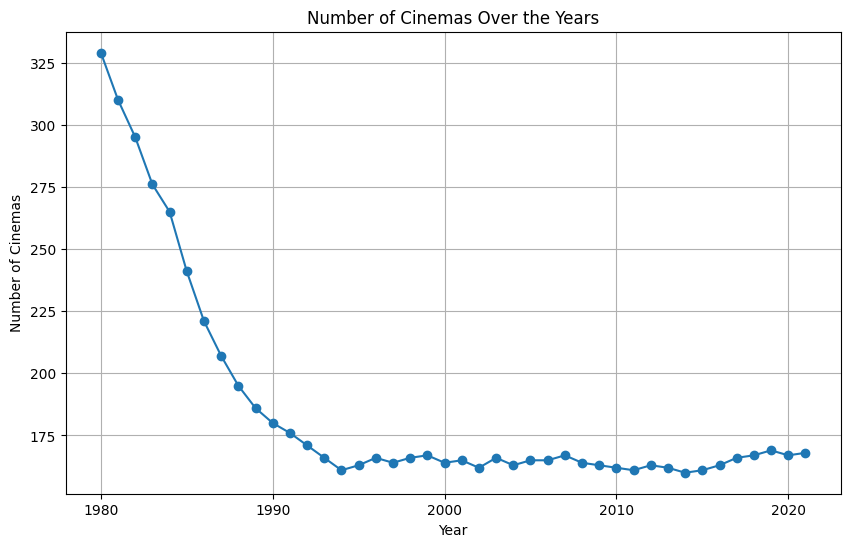

Year
1980    329
1981    310
1982    295
1983    276
1984    265
1985    241
1986    221
1987    207
1988    195
1989    186
1990    180
1991    176
1992    171
1993    166
1994    161
1995    163
1996    166
1997    164
1998    166
1999    167
2000    164
2001    165
2002    162
2003    166
2004    163
2005    165
2006    165
2007    167
2008    164
2009    163
2010    162
2011    161
2012    163
2013    162
2014    160
2015    161
2016    163
2017    166
2018    167
2019    169
2020    167
2021    168
Name: Cinemas, dtype: int64


In [9]:
# Group by year and get the count of cinemas
cinema_data['Year'] = pd.to_datetime(cinema_data['Year'], format='%Y')
cinema_by_year = cinema_data.groupby(cinema_data['Year'].dt.year)['Cinemas'].sum()
# Plot the data
plt.figure(figsize=(10, 6))
cinema_by_year.plot(kind='line', marker='o')
plt.title('Number of Cinemas Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Cinemas')
plt.grid(True)
plt.show()

# Display the table for the grouped data
print(cinema_by_year)

## Exercise 2

In this exercise, we are going to use the `penguins` dataset from the Seaborn package. The cell below loads the data

In [12]:
import seaborn as sns

In [13]:
penguins_data = sns.load_dataset("penguins")

Based on the `Penguins` dataset, answer the following questions:

1. Make a barplot that shows how many penguins there are of each species in the dataset. Support the plot by calculating the numbers.
2. Make a barplot that shows the average body mass for each species of penguin. Support the plot by calculating the numbers
3. Make a boxplots that shows the distribution of the body mass for each species of penguin. Support the plot by calculating the numbers.
4. Make a scatterplot that shows the correlation between body mass (in g) and flipper length (in mm). Support the plot by calculating the numbers.
5. Use boxplots and histograms to show how bill length, bill depth, flipper length and body mass varies between species and sex.
6. Visualise how the linear correlation between body mass and flipper length varies between species and sex.

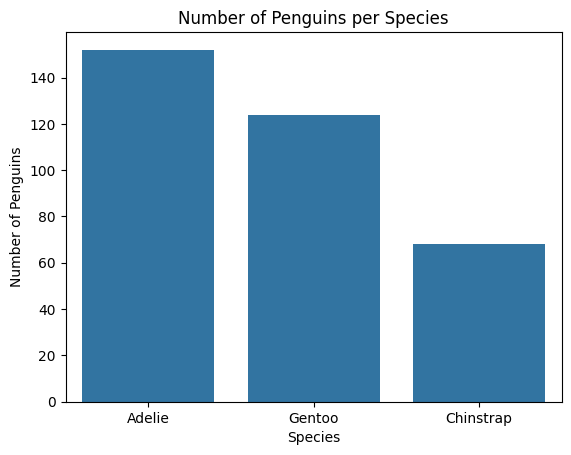

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


In [14]:
#01

# Barplot to show the number of penguins per species
species_count = penguins_data['species'].value_counts()
sns.barplot(x=species_count.index, y=species_count.values)
plt.title('Number of Penguins per Species')
plt.xlabel('Species')
plt.ylabel('Number of Penguins')
plt.show()

# Calculate the numbers to support the plot
print(species_count)

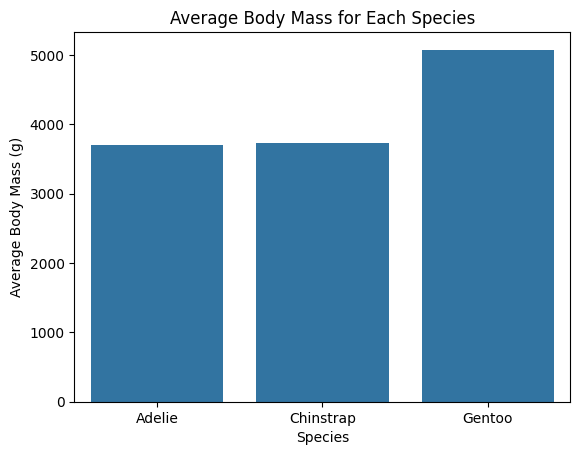

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
Name: body_mass_g, dtype: float64


In [15]:
#02


# Calculate the average body mass for each species
avg_mass = penguins_data.groupby('species')['body_mass_g'].mean()

# Create a barplot
sns.barplot(x=avg_mass.index, y=avg_mass.values)
plt.title('Average Body Mass for Each Species')
plt.xlabel('Species')
plt.ylabel('Average Body Mass (g)')
plt.show()

# Print the average body mass for each species
print(avg_mass)

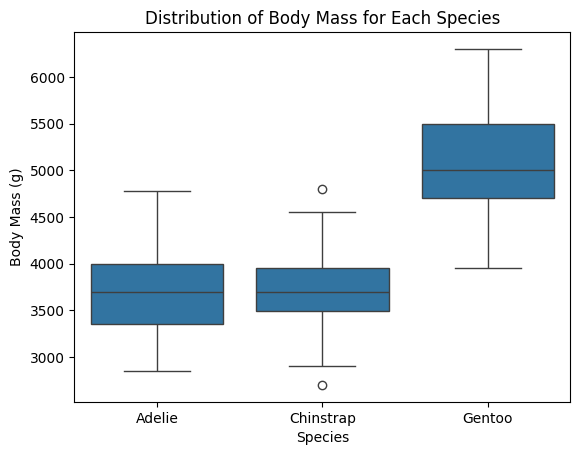

           count         mean         std     min     25%     50%     75%  \
species                                                                     
Adelie     151.0  3700.662252  458.566126  2850.0  3350.0  3700.0  4000.0   
Chinstrap   68.0  3733.088235  384.335081  2700.0  3487.5  3700.0  3950.0   
Gentoo     123.0  5076.016260  504.116237  3950.0  4700.0  5000.0  5500.0   

              max  
species            
Adelie     4775.0  
Chinstrap  4800.0  
Gentoo     6300.0  


In [16]:
#03


# Boxplot showing the distribution of body mass for each species
sns.boxplot(data=penguins_data, x='species', y='body_mass_g')
plt.title('Distribution of Body Mass for Each Species')
plt.xlabel('Species')
plt.ylabel('Body Mass (g)')
plt.show()

# Summary statistics to support the plot
body_mass_stats = penguins_data.groupby('species')['body_mass_g'].describe()
print(body_mass_stats)

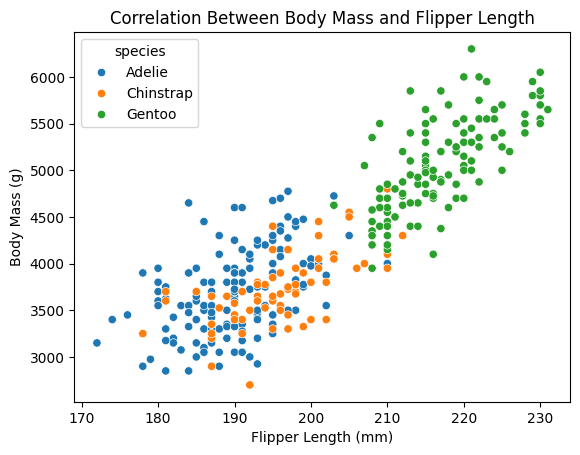

                   body_mass_g  flipper_length_mm
body_mass_g           1.000000           0.871202
flipper_length_mm     0.871202           1.000000


In [17]:
#04


# Scatterplot showing the relationship between body mass and flipper length
sns.scatterplot(data=penguins_data, x='flipper_length_mm', y='body_mass_g', hue='species')
plt.title('Correlation Between Body Mass and Flipper Length')
plt.xlabel('Flipper Length (mm)')
plt.ylabel('Body Mass (g)')
plt.show()

# Calculate the correlation between body mass and flipper length
correlation = penguins_data[['body_mass_g', 'flipper_length_mm']].corr()
print(correlation)

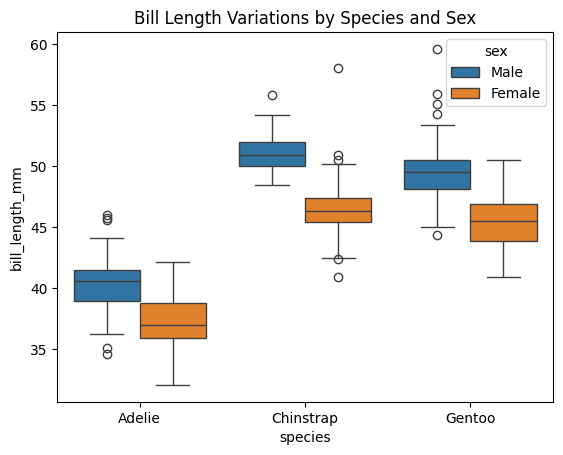

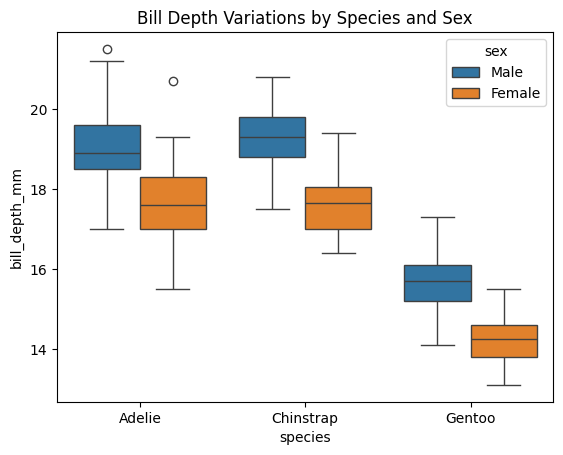

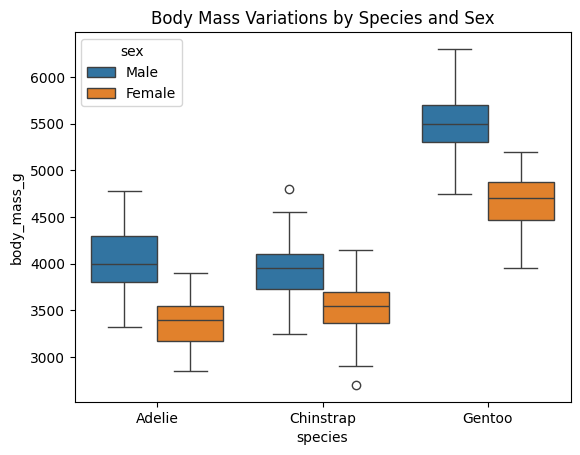

In [18]:
#05


# Boxplot showing how bill length varies between species and sex
sns.boxplot(data=penguins_data, x='species', y='bill_length_mm', hue='sex')
plt.title('Bill Length Variations by Species and Sex')
plt.show()

# Boxplot showing how bill depth varies between species and sex
sns.boxplot(data=penguins_data, x='species', y='bill_depth_mm', hue='sex')
plt.title('Bill Depth Variations by Species and Sex')
plt.show()

# Boxplot showing how body mass varies between species and sex
sns.boxplot(data=penguins_data, x='species', y='body_mass_g', hue='sex')
plt.title('Body Mass Variations by Species and Sex')
plt.show()

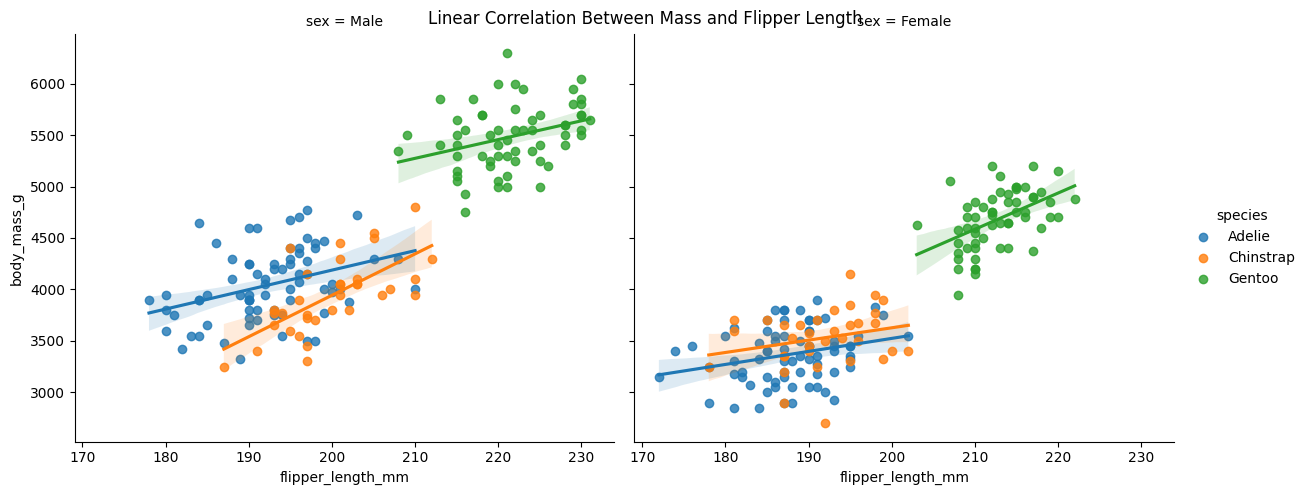

In [19]:
#06


# Scatterplot with linear correlation between body mass and flipper length, by species and sex
sns.lmplot(data=penguins_data, x='flipper_length_mm', y='body_mass_g', hue='species', col='sex', aspect=1.2)
plt.suptitle('Linear Correlation Between Mass and Flipper Length')
plt.show()

## Exercise 3

Do an exploratory data analysis of the adult dataset. The cell below loads the dataset from UCI Machine Learning Repository into a pandas dataframe called `adult_data`. It requires that you have installed the package `ucimlrepo`. (Otherwise the dataset is on moodle page for this class.)

In [20]:
!pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from ucimlrepo import fetch_ucirepo 
adult = fetch_ucirepo(id=2) 
X = adult.data.features 
y = adult.data.targets 
X["income"] = y
adult_data = X.copy()

adult_data

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [22]:
print(adult_data.head())

   age         workclass  fnlwgt  education  education-num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country income  
0          2174             0              40  United-States  <=50K  
1             0             0             

In [23]:
print("Shape of dataset:", adult_data.shape)
print("\nColumn names:")
print(adult_data.columns.tolist())

print("\nData types:")
print(adult_data.dtypes)

print("\nMissing values in each column:")
print(adult_data.isnull().sum())

Shape of dataset: (48842, 15)

Column names:
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Data types:
age               int64
workclass           str
fnlwgt            int64
education           str
education-num     int64
marital-status      str
occupation          str
relationship        str
race                str
sex                 str
capital-gain      int64
capital-loss      int64
hours-per-week    int64
native-country      str
income              str
dtype: object

Missing values in each column:
age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtyp

## Exercise 4 (Optional)

Complete an exploratory data analysis of the titanic dataset (it is on moodle). (Remember, you can load it in as `titanic_data = pd.read_csv("titanic_survival_data.csv")`)

## Exercise 5 (Optional)

Do an exploratory data analysis of the diabetes dataset. The cell below loads the dataset from the scikit learn package into the pandas dataframe called `diabetes_data`.

In [ ]:
from sklearn.datasets import load_diabetes
d_data = load_diabetes(as_frame=True)
diabetes_data = d_data.data
diabetes_data["Target"] = d_data.target

diabetes_data